# Student Score Prediction — Complete ML Pipeline

**Goal**: Predict a student's `Final Score` using study habits and academic performance features.

| Phase | Description |
|---|---|
| 1 | Data Loading & Exploration (EDA) |
| 2 | Data Cleaning |
| 3 | Feature Engineering & Encoding |
| 4 | Train / Test Split |
| 5 | Model Training |
| 6 | Model Evaluation |
| 7 | Visualization |
| 8 | Predict on New Student |

## Phase 1 — Data Loading & Exploration (EDA)

Before building any model, understand your data:
- How many rows/columns?
- What data types exist?
- Are there missing values?
- What does the distribution look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # suppress minor sklearn/pandas warnings

# --- Load Data ---
df = pd.read_csv('student_dataset_1000.csv')

print('=== Dataset Shape ===')
print(f'{df.shape[0]} rows x {df.shape[1]} columns')  # rows=students, cols=features

print('\n=== First 3 Rows ===')
print(df.head(3).to_string())

print('\n=== Column Names & Data Types ===')
print(df.dtypes)

# isnull().sum() counts NaN per column
print('\n=== Missing Values per Column ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

print('\n=== Duplicate Rows ===')
print(f'{df.duplicated().sum()} duplicate row(s) found')

# describe() gives count, mean, std, min, 25%, 50%, 75%, max
print('\n=== Numeric Column Statistics ===')
print(df.describe().round(2).to_string())

print('\n=== Categorical Column Value Counts ===')
for col in ['Gender','Department','Grade','Extracurricular Activity','Internet Access']:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())


=== Dataset Shape ===
1000 rows x 19 columns

=== First 3 Rows ===
   Student ID First Name Last Name                           Email  Gender  Age Department  Attendance %  Midterm Score  Final Score  Assignment Average  Quizzes Average  Participation Score  Project Score  Total Score Grade  Study Hours per Week Extracurricular Activity Internet Access
0           1       Ritu    Tiwari      ritu.tiwari722@outlook.com    Male   23        ECE         65.90             76           88               57.75            92.37                50.21          73.46        72.96     B                     8                       No             Yes
1           2    Sandeep   Agarwal  sandeep.agarwal245@outlook.com    Male   24        ECE         65.79             85           46               79.91            77.63                75.82          71.60        72.66     B                    29                      Yes             Yes
2           3       Neha    Saxena      neha.saxena624@outlook.com  F

## Phase 2 — Data Cleaning

Remove columns that are:
- **Identifiers** (Student ID, Email, Name) — unique per row, no predictive value
- **Leakage** (Total Score, Grade) — computed FROM Final Score, would cheat the model

> Leakage = giving the model info it would not have at real prediction time.

In [2]:
# Drop identifier columns — no predictive signal
drop_ids = ['Student ID', 'First Name', 'Last Name', 'Email']

# Drop leakage columns — derived from Final Score, unfair advantage
drop_leakage = ['Total Score', 'Grade']

df_clean = df.drop(columns=drop_ids + drop_leakage)

print(f'Columns removed : {drop_ids + drop_leakage}')
print(f'Remaining columns ({df_clean.shape[1]}): {list(df_clean.columns)}')

num_cols = df_clean.select_dtypes(include='number').columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

# Median is more robust than mean when outliers exist
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Most frequent value for categorical missing data
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f'\nMissing values after cleaning: {df_clean.isnull().sum().sum()}')
print(f'Numeric columns  : {num_cols}')
print(f'Categorical cols : {cat_cols}')


Columns removed : ['Student ID', 'First Name', 'Last Name', 'Email', 'Total Score', 'Grade']
Remaining columns (13): ['Gender', 'Age', 'Department', 'Attendance %', 'Midterm Score', 'Final Score', 'Assignment Average', 'Quizzes Average', 'Participation Score', 'Project Score', 'Study Hours per Week', 'Extracurricular Activity', 'Internet Access']

Missing values after cleaning: 0
Numeric columns  : ['Age', 'Attendance %', 'Midterm Score', 'Final Score', 'Assignment Average', 'Quizzes Average', 'Participation Score', 'Project Score', 'Study Hours per Week']
Categorical cols : ['Gender', 'Department', 'Extracurricular Activity', 'Internet Access']


## Phase 3 — Feature Engineering & Encoding

ML models need numbers — encode all categorical columns:
- **LabelEncoder** for binary (Yes/No, Male/Female)
- **get_dummies** for multi-class (Department)
- Check correlations to see which features matter most

In [4]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()  # always work on a copy

# LabelEncoder maps each string to integer (alphabetical order)
binary_cols = ['Gender', 'Extracurricular Activity', 'Internet Access']
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# get_dummies creates one column per dept (One-Hot Encoding)
# drop_first=True avoids multicollinearity (dummy variable trap)
df_model = pd.get_dummies(df_model, columns=['Department'], drop_first=True)
print(f'\nDept dummy columns: {[c for c in df_model.columns if "Department" in c]}')

# Define X (features) and y (target)
target = 'Final Score'
y = df_model[target]              # what we want to predict
X = df_model.drop(columns=[target])  # everything else is input

print(f'\nFeatures ({X.shape[1]}): {list(X.columns)}')

# Correlation with target — higher absolute value = stronger relationship
print(f'\n=== Feature Correlation with Final Score ===')
corr = df_model.corr(numeric_only=True)[target].drop(target).sort_values(ascending=False)
for feat, val in corr.items():
    bar = chr(9608) * int(abs(val) * 20)
    print(f'  {feat:<30} {val:>+.3f}  {bar}')


Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Extracurricular Activity: {'No': np.int64(0), 'Yes': np.int64(1)}
Internet Access: {'No': np.int64(0), 'Yes': np.int64(1)}

Dept dummy columns: ['Department_CE', 'Department_CSE', 'Department_ECE', 'Department_EE', 'Department_IT', 'Department_MBA', 'Department_ME']

Features (18): ['Gender', 'Age', 'Attendance %', 'Midterm Score', 'Assignment Average', 'Quizzes Average', 'Participation Score', 'Project Score', 'Study Hours per Week', 'Extracurricular Activity', 'Internet Access', 'Department_CE', 'Department_CSE', 'Department_ECE', 'Department_EE', 'Department_IT', 'Department_MBA', 'Department_ME']

=== Feature Correlation with Final Score ===
  Department_ME                  +0.044  
  Participation Score            +0.035  
  Project Score                  +0.021  
  Midterm Score                  +0.018  
  Department_CSE                 +0.014  
  Internet Access                +0.014  
  Study Hours per Week           +0.009  

## Phase 4 — Train / Test Split

- **Train (80%)** — model learns from this
- **Test (20%)** — held out, never seen during training

> Evaluating on training data gives a falsely optimistic score. Always test on unseen data.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# test_size=0.2 = 20% test, 80% train
# random_state=42 = reproducible split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total  : {len(X)}')
print(f'Train  : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test   : {len(X_test)} samples  ({len(X_test)/len(X)*100:.0f}%)')

scaler = StandardScaler()

# fit_transform on train: learns mean+std FROM training data only
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test: uses same stats learned from train (no peeking)
X_test_scaled  = scaler.transform(X_test)

print('\nStandardScaler applied — fit on train only')


Total  : 1000
Train  : 800 samples (80%)
Test   : 200 samples  (20%)

StandardScaler applied — fit on train only


## Phase 5 — Model Training

Linear Regression finds the best-fit hyperplane:
```
Final Score = w1*StudyHours + w2*Attendance + w3*Midterm + ... + bias
```
Each weight `w` shows how much that feature pushes the score up or down.

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()  # create model (no learning yet)

# fit() is the actual learning step
model.fit(X_train_scaled, y_train)

print(f'Intercept: {model.intercept_:.2f} (base score when all features = 0)')

# coef_ has one weight per feature
# After scaling, larger |coef| = stronger influence on Final Score
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print('\n=== Feature Coefficients ===')
print(f'{"Feature":<32} {"Coef":>8}   Impact')
print('-'*58)
for _, row in coef_df.iterrows():
    direction = 'raises score' if row['Coefficient'] > 0 else 'lowers score'
    bar = chr(9608) * int(abs(row['Coefficient']) / coef_df['Coefficient'].abs().max() * 15)
    print(f"{row['Feature']:<32} {row['Coefficient']:>+8.3f}   {direction}  {bar}")


Intercept: 70.49 (base score when all features = 0)

=== Feature Coefficients ===
Feature                              Coef   Impact
----------------------------------------------------------
Department_ME                      +1.014   raises score  ███████████████
Participation Score                +0.778   raises score  ███████████
Attendance %                       -0.767   lowers score  ███████████
Department_EE                      -0.622   lowers score  █████████
Internet Access                    +0.537   raises score  ███████
Midterm Score                      +0.524   raises score  ███████
Age                                -0.517   lowers score  ███████
Project Score                      +0.505   raises score  ███████
Department_IT                      -0.494   lowers score  ███████
Gender                             +0.338   raises score  █████
Extracurricular Activity           +0.293   raises score  ████
Department_CSE                     +0.239   raises score  ███
Quizzes

## Phase 6 — Model Evaluation

| Metric | Meaning | Good when |
|---|---|---|
| **MAE** | Average error in score units | Lower |
| **MSE** | Mean squared error (penalises big errors more) | Lower |
| **RMSE** | Same unit as score; typical prediction error | Lower |
| **R²** | % of variance the model explains | Closer to 1.0 |

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Always evaluate on TEST set — data the model never saw
y_pred_test  = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)  # compare to detect overfitting

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n--- {label} ---')
    print(f'  MAE  : {mae:.2f}  -> off by ~{mae:.1f} marks on average')
    print(f'  MSE  : {mse:.2f}  -> mean squared error')
    print(f'  RMSE : {rmse:.2f}  -> typical error is ~{rmse:.1f} marks')
    print(f'  R2   : {r2:.4f} -> explains {r2*100:.1f}% of score variance')
    return r2

r2_train = evaluate(y_train, y_pred_train, 'Training Set')
r2_test  = evaluate(y_test,  y_pred_test,  'Test Set (unseen)')

# Overfitting: big gap between train and test R2
gap = r2_train - r2_test
print(f'\n=== Overfit Check: gap = {gap:.4f}', end='  ')
print('Good fit' if gap < 0.05 else 'Possible overfit' if gap < 0.15 else 'Overfitting!')

# 5-fold CV: more reliable than one train/test split
cv = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')
print(f'\n=== 5-Fold Cross-Validation R2 ===')
for i, s in enumerate(cv, 1): print(f'  Fold {i}: {s:.4f}')
print(f'  Mean: {cv.mean():.4f} +/- {cv.std():.4f}  (low std = stable model)')



--- Training Set ---
  MAE  : 15.18  -> off by ~15.2 marks on average
  MSE  : 311.83  -> mean squared error
  RMSE : 17.66  -> typical error is ~17.7 marks
  R2   : 0.0146 -> explains 1.5% of score variance

--- Test Set (unseen) ---
  MAE  : 15.65  -> off by ~15.7 marks on average
  MSE  : 330.61  -> mean squared error
  RMSE : 18.18  -> typical error is ~18.2 marks
  R2   : -0.0420 -> explains -4.2% of score variance

=== Overfit Check: gap = 0.0566  Possible overfit

=== 5-Fold Cross-Validation R2 ===
  Fold 1: -0.0328
  Fold 2: -0.0588
  Fold 3: -0.0285
  Fold 4: -0.0090
  Fold 5: -0.0657
  Mean: -0.0390 +/- 0.0208  (low std = stable model)


## Phase 7 — Visualization

4 key plots:
1. **Score Distribution** — spread of the target variable
2. **Actual vs Predicted** — points near diagonal = accurate model
3. **Residual Plot** — errors must be random around 0 (no pattern)
4. **Feature Importances** — which features drive predictions?

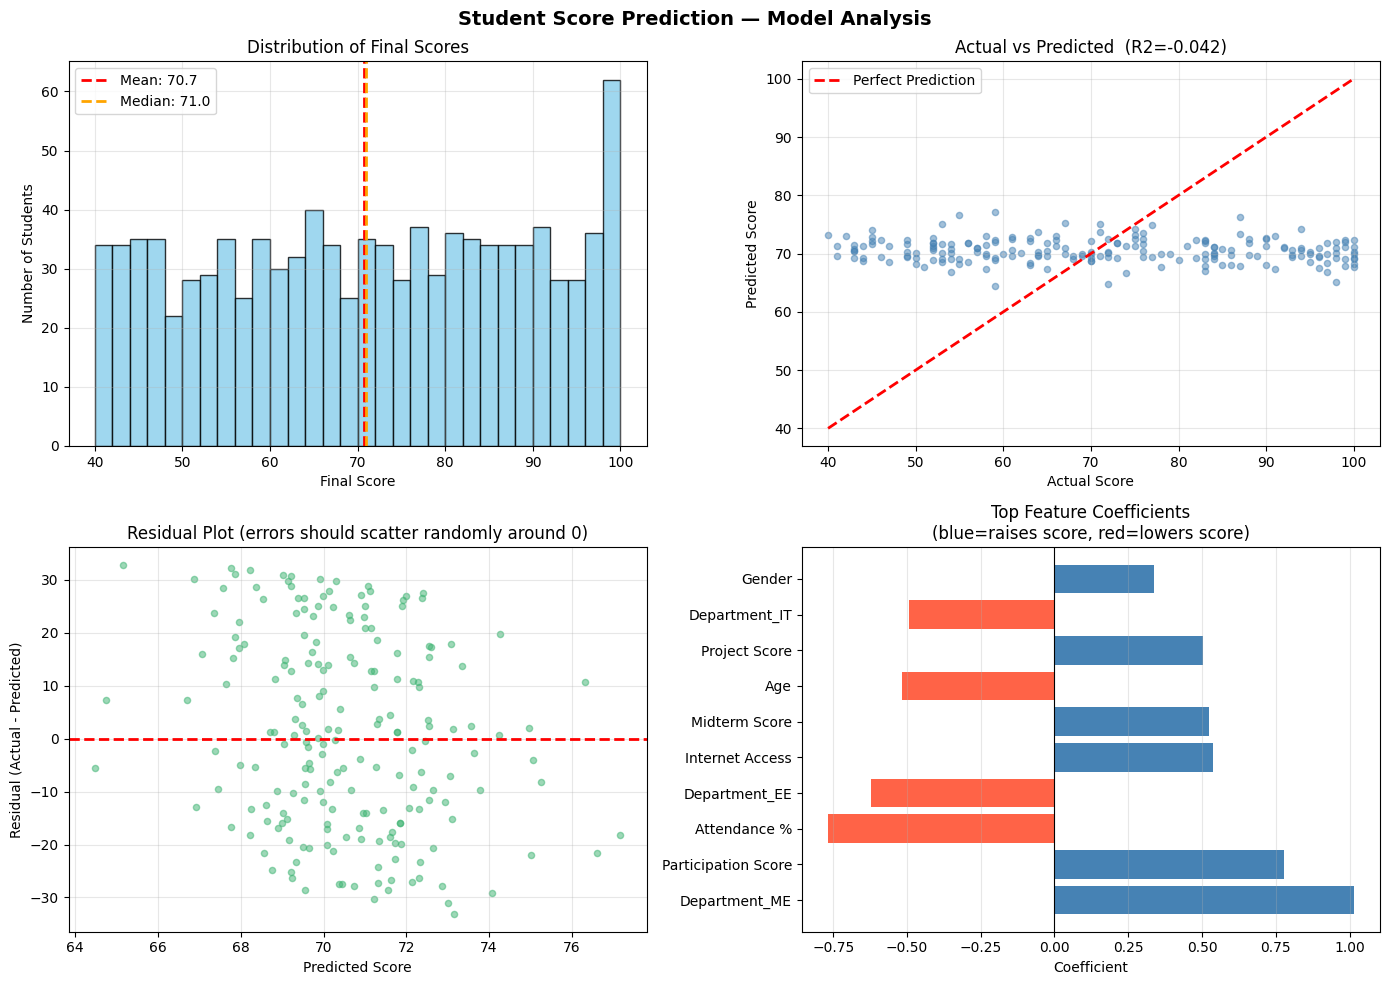

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Score Prediction — Model Analysis', fontsize=14, fontweight='bold')

# Plot 1: Score Distribution
ax1 = axes[0, 0]
ax1.hist(y, bins=30, color='skyblue', edgecolor='black', alpha=0.8)
ax1.axvline(y.mean(),   color='red',    linestyle='--', lw=2, label=f'Mean: {y.mean():.1f}')
ax1.axvline(y.median(), color='orange', linestyle='--', lw=2, label=f'Median: {y.median():.1f}')
ax1.set_title('Distribution of Final Scores')
ax1.set_xlabel('Final Score'); ax1.set_ylabel('Number of Students')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted
# Points close to red diagonal = good predictions
ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', s=20)
lo, hi = y.min(), y.max()
ax2.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect Prediction')
ax2.set_title(f'Actual vs Predicted  (R2={r2_test:.3f})')
ax2.set_xlabel('Actual Score'); ax2.set_ylabel('Predicted Score')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Plot 3: Residual Plot
# residual = actual - predicted
# Good model: random scatter around 0, no curve or funnel
residuals = y_test.values - y_pred_test
ax3 = axes[1, 0]
ax3.scatter(y_pred_test, residuals, alpha=0.5, color='mediumseagreen', s=20)
ax3.axhline(0, color='red', linestyle='--', lw=2)  # zero-error reference
ax3.set_title('Residual Plot (errors should scatter randomly around 0)')
ax3.set_xlabel('Predicted Score'); ax3.set_ylabel('Residual (Actual - Predicted)')
ax3.grid(True, alpha=0.3)

# Plot 4: Top Feature Coefficients
# After scaling, |coef| shows relative feature importance
ax4 = axes[1, 1]
top = coef_df.head(10)
colors = ['tomato' if c < 0 else 'steelblue' for c in top['Coefficient']]
ax4.barh(top['Feature'], top['Coefficient'], color=colors)
ax4.axvline(0, color='black', lw=0.8)
ax4.set_title('Top Feature Coefficients\n(blue=raises score, red=lowers score)')
ax4.set_xlabel('Coefficient'); ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## Phase 8 — Predict on a New Student

Use the trained model on a brand new student.
Must use the **same scaler** — do NOT re-fit it on new data.

In [9]:
# Build new student row matching training feature columns exactly
new_student = pd.DataFrame([{
    'Gender': 1,                    # 1=Male (from LabelEncoder in Phase 3)
    'Age': 21,
    'Attendance %': 85.0,
    'Midterm Score': 72,
    'Assignment Average': 78.0,
    'Quizzes Average': 80.0,
    'Participation Score': 70.0,
    'Project Score': 75.0,
    'Study Hours per Week': 20,
    'Extracurricular Activity': 1,  # 1=Yes
    'Internet Access': 1,           # 1=Yes
}])

# Add department dummy columns — fill 0 for all, set 1 for student's dept
dept_cols = [c for c in X.columns if 'Department_' in c]
for col in dept_cols:
    new_student[col] = 0
if 'Department_CSE' in dept_cols:
    new_student['Department_CSE'] = 1

# reindex ensures column order exactly matches training data
new_student = new_student.reindex(columns=X.columns, fill_value=0)

# Use same scaler fitted on training data — do NOT call fit again
new_scaled = scaler.transform(new_student)

# predict() returns array; [0] gets the single value
score = float(model.predict(new_scaled)[0])
score = np.clip(score, 0, 100)  # clamp to valid range

# Grade mapping
grade = 'A' if score>=90 else 'B' if score>=75 else 'C' if score>=60 else 'D' if score>=45 else 'F'

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('=== New Student Prediction ===')
print(f'  Study Hours/Week : 20')
print(f'  Attendance       : 85%')
print(f'  Midterm Score    : 72')
print(f'\n  Predicted Score  : {score:.1f} / 100')
print(f'  Estimated Grade  : {grade}')
print(f'  Confidence range : {score-rmse:.1f} to {score+rmse:.1f}  (+/- {rmse:.1f} marks)')


=== New Student Prediction ===
  Study Hours/Week : 20
  Attendance       : 85%
  Midterm Score    : 72

  Predicted Score  : 71.9 / 100
  Estimated Grade  : C
  Confidence range : 53.7 to 90.1  (+/- 18.2 marks)


## Summary — All 8 Phases

```
Phase 1  EDA         shape, dtypes, missing values, distributions
Phase 2  Cleaning    drop IDs + leakage cols, impute missing
Phase 3  Encoding    LabelEncoder (binary), get_dummies (multi-class)
Phase 4  Split       80/20 train_test_split, StandardScaler on train only
Phase 5  Training    model.fit() — inspect coef_ and intercept_
Phase 6  Evaluation  MAE/MSE/RMSE/R2 on TEST set, overfit check, 5-fold CV
Phase 7  Plots       distribution, actual vs predicted, residuals, importances
Phase 8  Predict     reindex columns, scaler.transform(), clip to 0-100
```

**Key rules**
- Never fit scaler on test data — only transform
- Never use leakage features as model inputs
- Train R2 vs Test R2 gap < 0.05 = good fit
- Cross-validation is more reliable than a single split